In [1]:
import pandas as pd

#Import data 
data = pd.read_csv("road_accident_dataset.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132000 entries, 0 to 131999
Data columns (total 30 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Country                      132000 non-null  object 
 1   Year                         132000 non-null  int64  
 2   Month                        132000 non-null  object 
 3   Day of Week                  132000 non-null  object 
 4   Time of Day                  132000 non-null  object 
 5   Urban/Rural                  132000 non-null  object 
 6   Road Type                    132000 non-null  object 
 7   Weather Conditions           132000 non-null  object 
 8   Visibility Level             132000 non-null  float64
 9   Number of Vehicles Involved  132000 non-null  int64  
 10  Speed Limit                  132000 non-null  int64  
 11  Driver Age Group             132000 non-null  object 
 12  Driver Gender                132000 non-null  object 
 13 

C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_26880\2125661819.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')
C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_26880\2125661819.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')
C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_26880\2125661819.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha='right')
C:\Users\ACER NITRO\AppData\Local\Temp\ipykernel_26880\2125661819.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xtickla

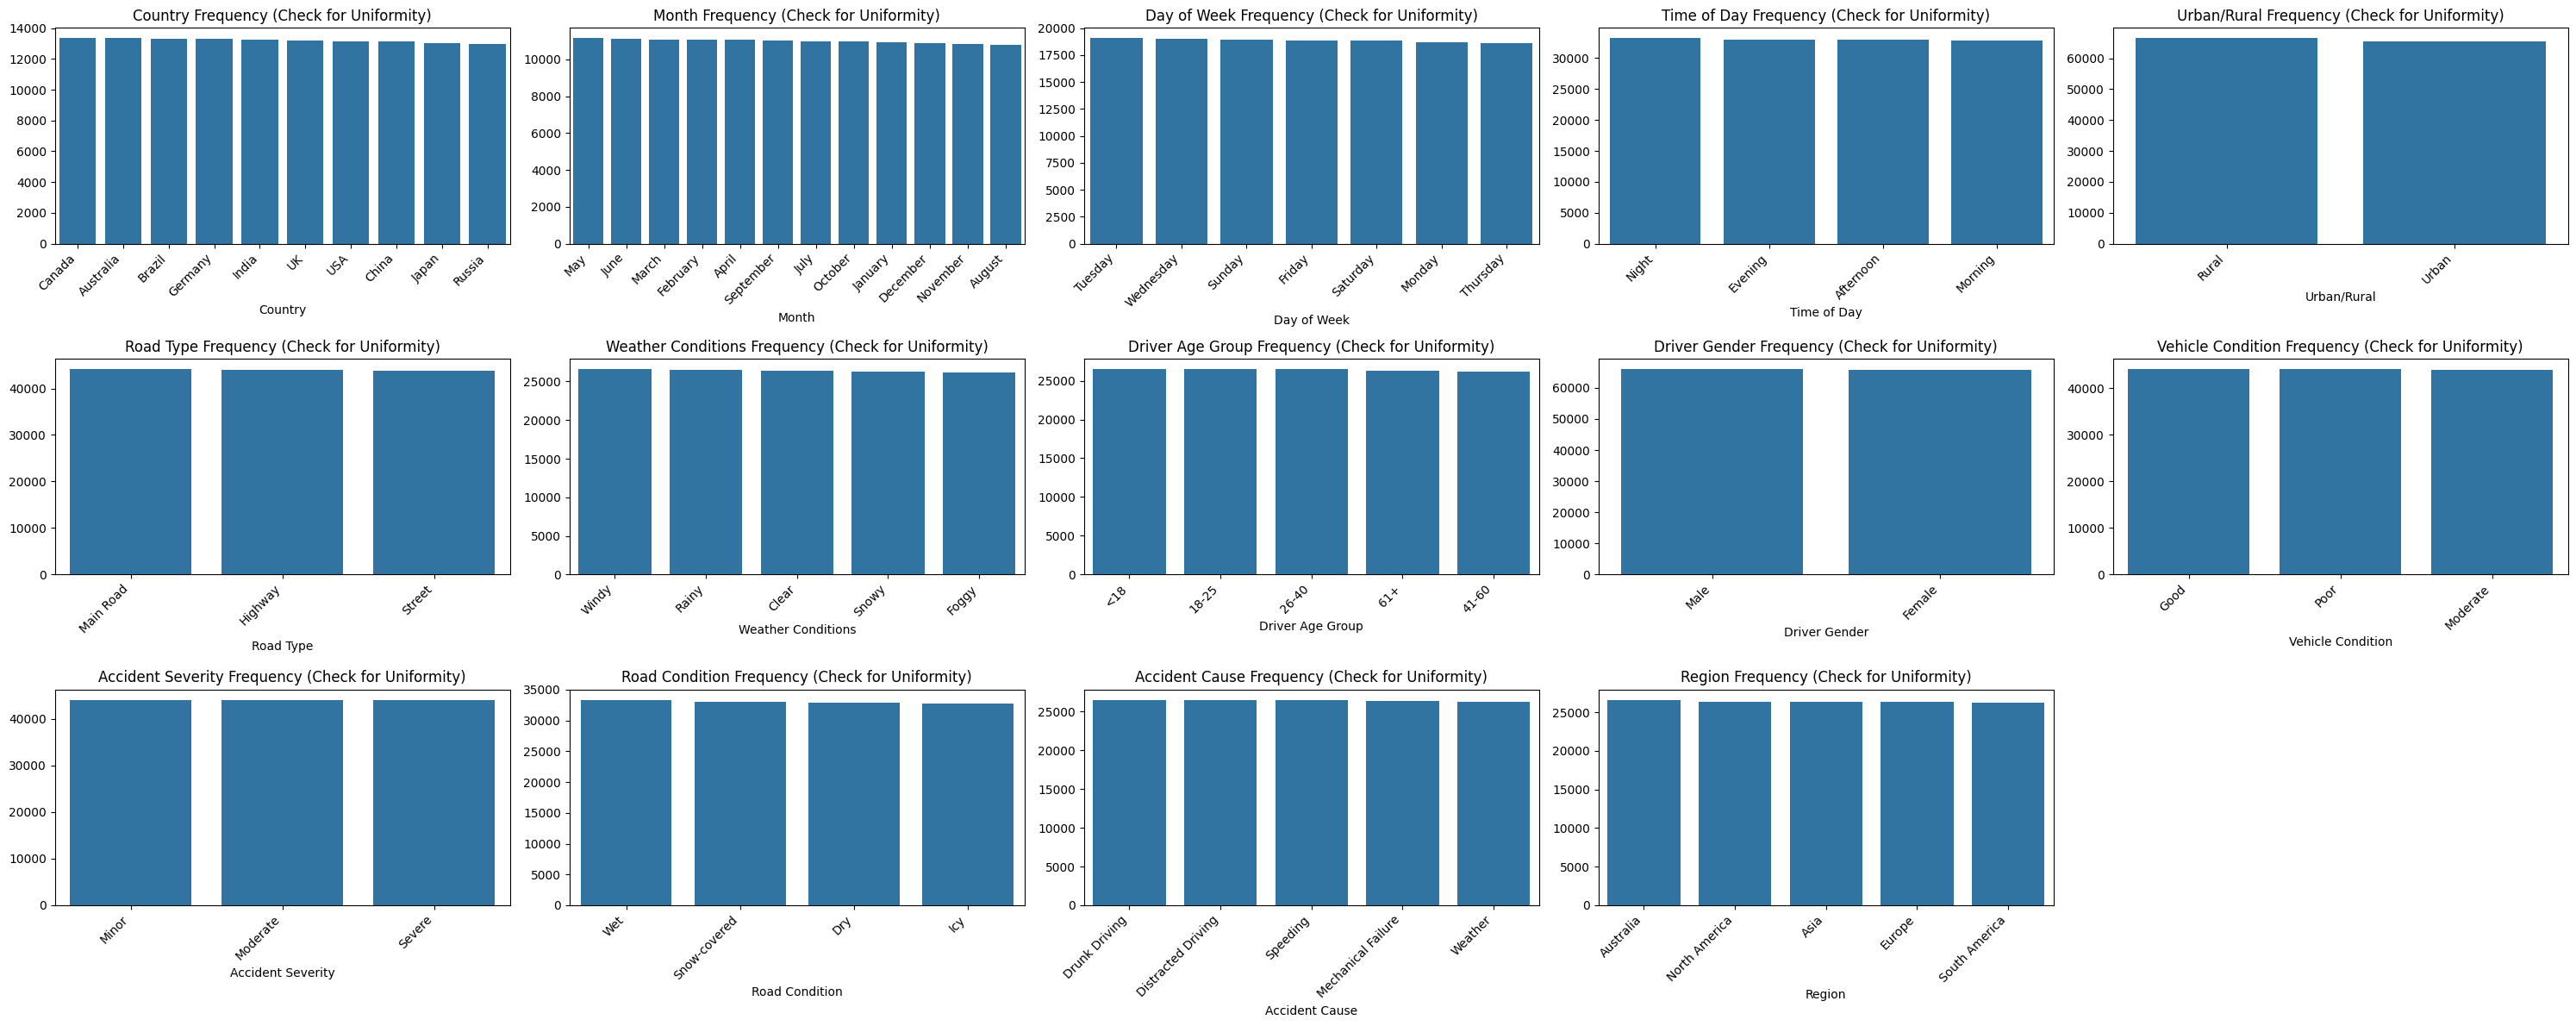

Country:
Country
Canada       13349
Australia    13345
Brazil       13318
Germany      13293
India        13238
UK           13186
USA          13125
China        13121
Japan        13049
Russia       12976
Name: count, dtype: int64

Month:
Month
May          11158
June         11122
March        11072
February     11064
April        11063
September    11047
July         11000
October      10986
January      10952
December     10909
November     10836
August       10791
Name: count, dtype: int64

Day of Week:
Day of Week
Tuesday      19061
Wednesday    19001
Sunday       18939
Friday       18854
Saturday     18818
Monday       18708
Thursday     18619
Name: count, dtype: int64

Time of Day:
Time of Day
Night        33231
Evening      33021
Afternoon    32960
Morning      32788
Name: count, dtype: int64

Urban/Rural:
Urban/Rural
Rural    66502
Urban    65498
Name: count, dtype: int64

Road Type:
Road Type
Main Road    44197
Highway      43920
Street       43883
Name: count, dtype: int64

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# Set up the figure: one row per variable, adjustable height
n_cols = 5  # number of subplots per row
n_rows = (len(cat_cols) + n_cols - 1) // n_cols  # calculate number of rows needed

plt.figure(figsize=(n_cols*6, n_rows*4))

for i, col in enumerate(cat_cols):
    counts = data[col].value_counts()
    ax = plt.subplot(n_rows, n_cols, i+1)  # subplot position
    sns.barplot(x=counts.index, y=counts.values, ax=ax)
    ax.set_title(f"{col} Frequency (Check for Uniformity)")
    ax.set_xticklabels(counts.index, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Optionally, print all counts together
for col in cat_cols:
    counts = data[col].value_counts()
    print(f"{col}:\n{counts}\n")


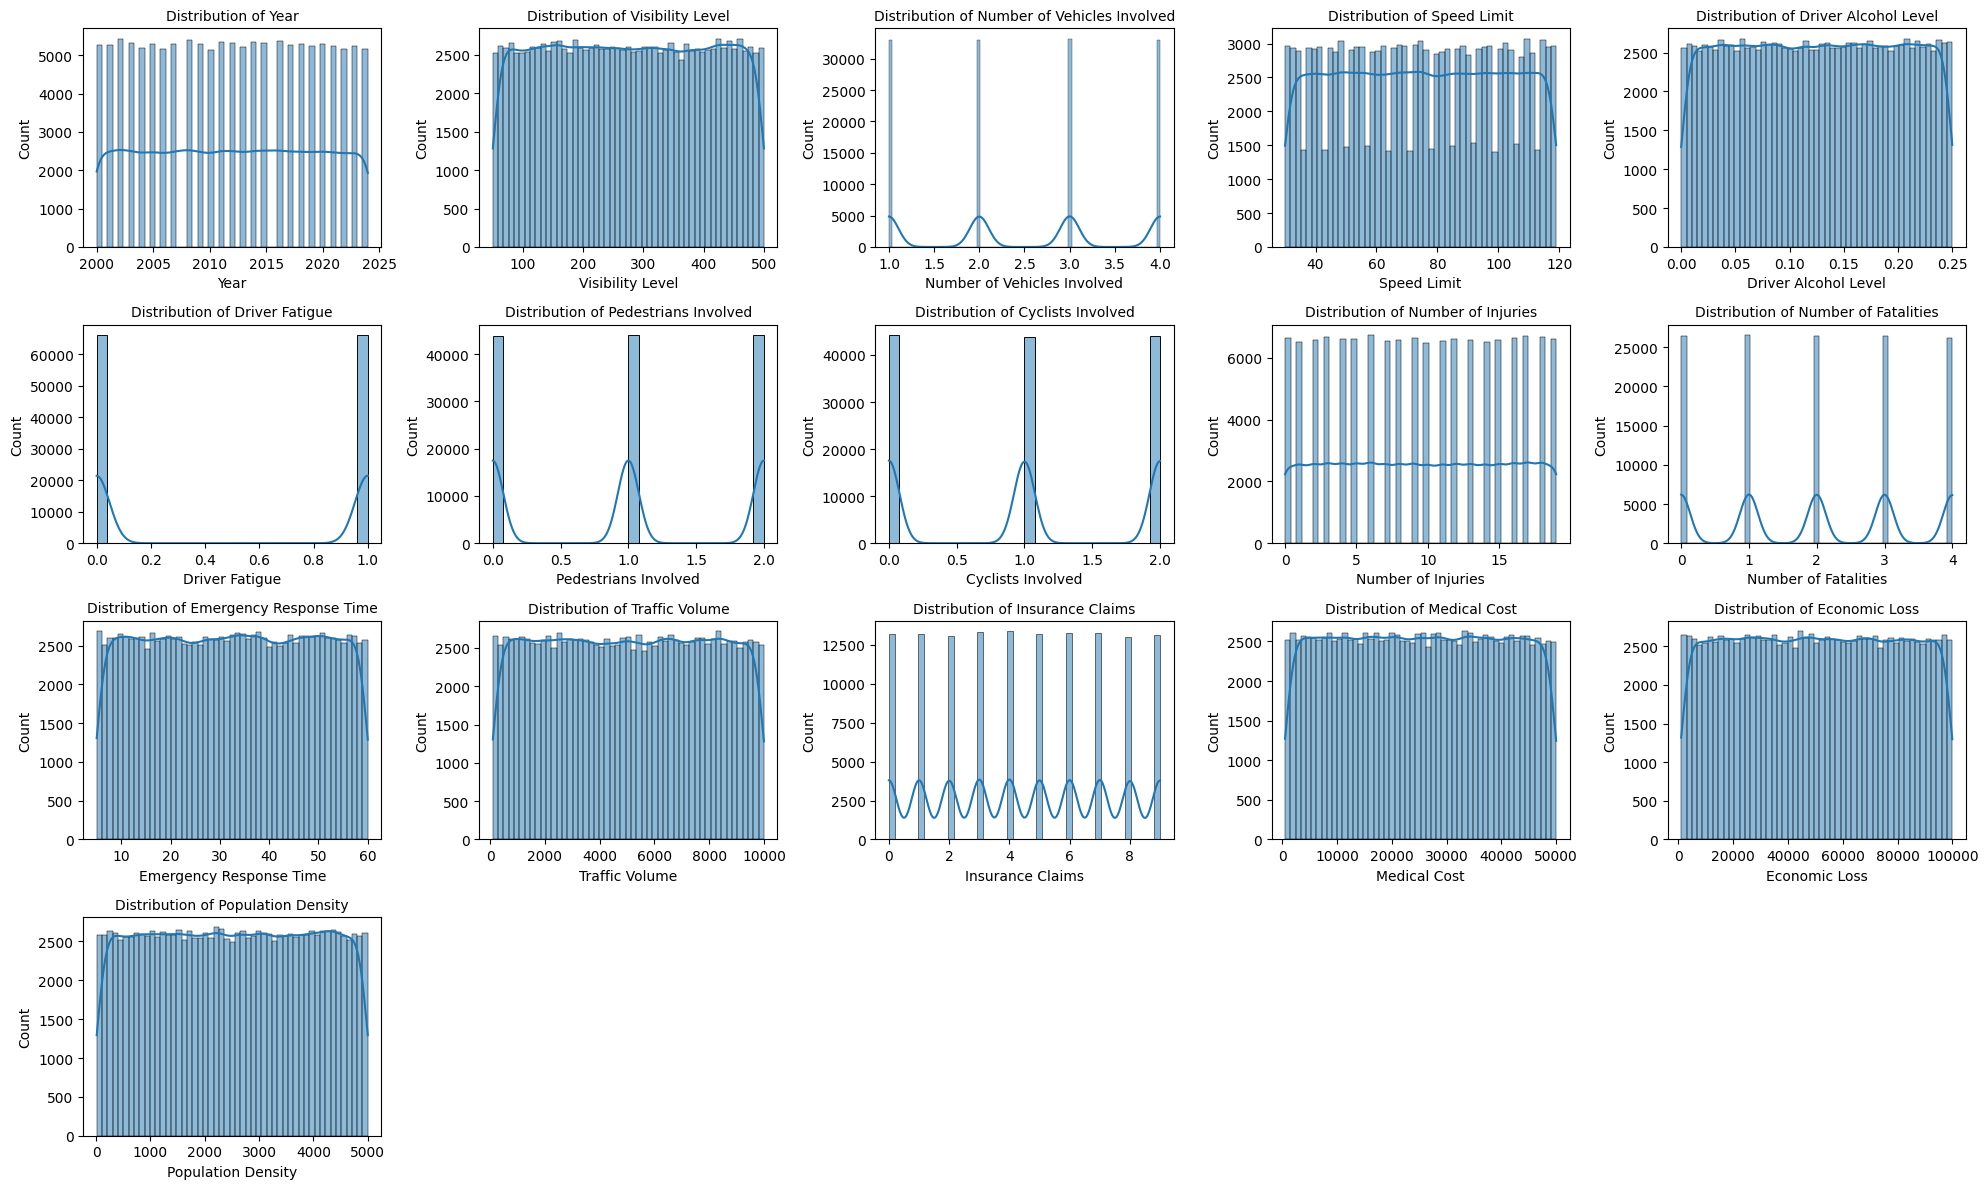

Year                           0.001133
Visibility Level               0.002267
Number of Vehicles Involved   -0.002733
Speed Limit                   -0.000751
Driver Alcohol Level          -0.002366
Driver Fatigue                -0.002303
Pedestrians Involved          -0.001419
Cyclists Involved              0.003025
Number of Injuries             0.000651
Number of Fatalities           0.004409
Emergency Response Time       -0.001649
Traffic Volume                 0.001068
Insurance Claims               0.002146
Medical Cost                   0.002779
Economic Loss                  0.003046
Population Density            -0.001587
dtype: float64

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Number of subplots per row
n_cols = 5
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols*4, n_rows*3))  # width scales with number of columns

for i, col in enumerate(num_cols):
    ax = plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}", fontsize=10)

plt.tight_layout()
plt.show()


# Check skewness
data[num_cols].skew()


Continuous Features: ['Year', 'Visibility Level', 'Number of Vehicles Involved', 'Speed Limit', 'Driver Alcohol Level', 'Pedestrians Involved', 'Cyclists Involved', 'Number of Injuries', 'Number of Fatalities', 'Emergency Response Time', 'Traffic Volume', 'Insurance Claims', 'Medical Cost', 'Economic Loss', 'Population Density']


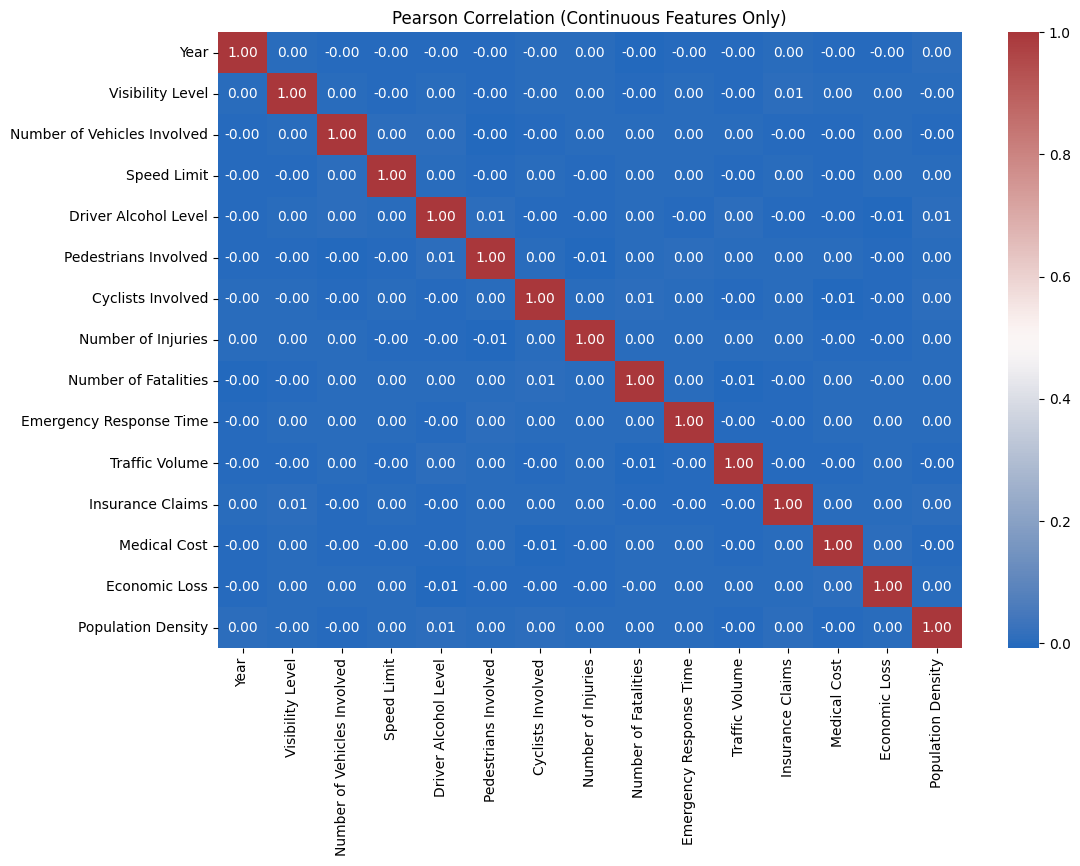

In [9]:
# Select columns that are numeric
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# Keep only continuous features (unique values > 2)
continuous_cols = [col for col in num_cols if data[col].nunique() > 2]

print("Continuous Features:", continuous_cols)
plt.figure(figsize=(12,8))
sns.heatmap(data[continuous_cols].corr(method='pearson'), annot=True,fmt=".2f",  cmap='vlag')
plt.title("Pearson Correlation (Continuous Features Only)")
plt.show()



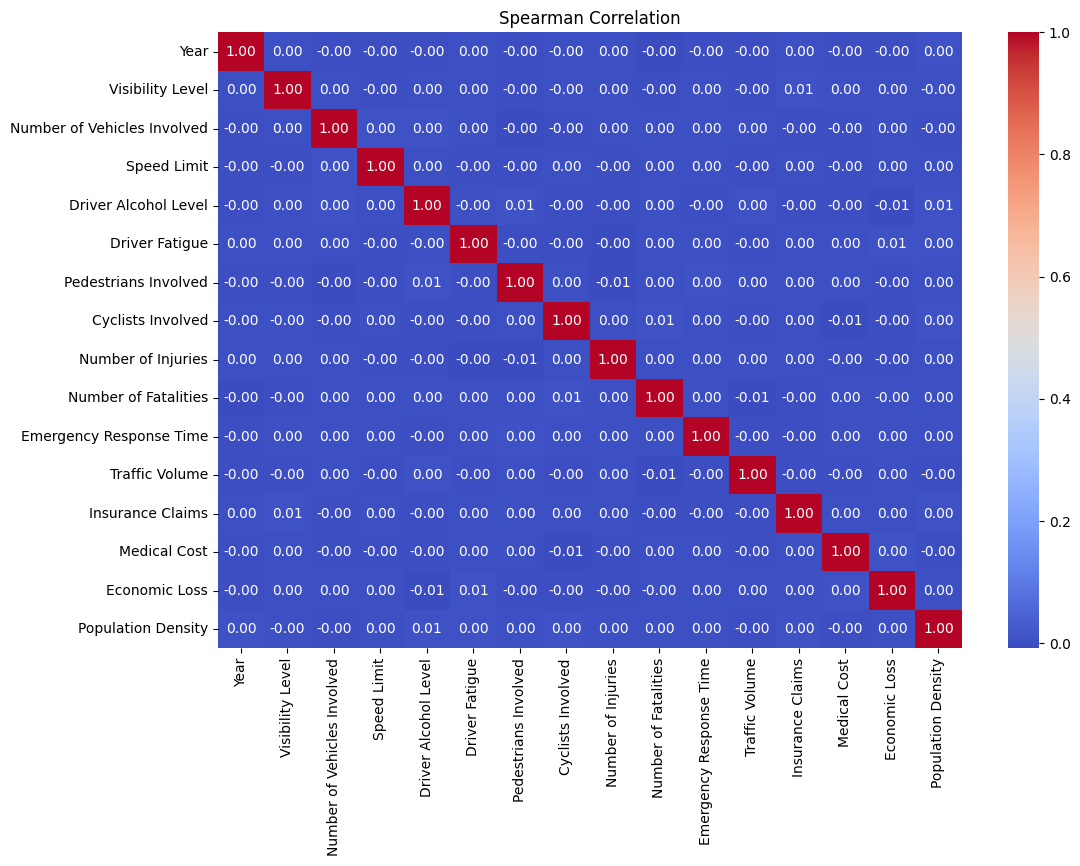

In [13]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(12,8))
sns.heatmap(data[num_cols].corr(method='spearman'), annot=True, fmt=".2f",cmap='coolwarm')
plt.title("Spearman Correlation")
plt.show()

In [15]:
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Select categorical columns
cat_cols = data.select_dtypes(include=['object', 'category']).columns

# Encode categoricals
encoded_data = data.copy()
for col in cat_cols:
    encoded_data[col] = LabelEncoder().fit_transform(encoded_data[col])

# Min-max scale for Chi2
X = MinMaxScaler().fit_transform(encoded_data[cat_cols])
y = encoded_data['Accident Severity']   # <-- change if your label column is different

chi_scores, p_values = chi2(X, y)

for col, score, p in zip(cat_cols, chi_scores, p_values):
    print(f"{col} → Chi-square: {score:.2f} | p-value: {p:.5f}")


Country → Chi-square: 0.17 | p-value: 0.91638
Month → Chi-square: 0.39 | p-value: 0.82441
Day of Week → Chi-square: 0.10 | p-value: 0.95183
Time of Day → Chi-square: 0.64 | p-value: 0.72570
Urban/Rural → Chi-square: 0.67 | p-value: 0.71693
Road Type → Chi-square: 2.76 | p-value: 0.25144
Weather Conditions → Chi-square: 0.39 | p-value: 0.82282
Driver Age Group → Chi-square: 1.26 | p-value: 0.53244
Driver Gender → Chi-square: 2.40 | p-value: 0.30182
Vehicle Condition → Chi-square: 0.43 | p-value: 0.80531
Accident Severity → Chi-square: 44041.64 | p-value: 0.00000
Road Condition → Chi-square: 0.83 | p-value: 0.66109
Accident Cause → Chi-square: 1.49 | p-value: 0.47592
Region → Chi-square: 0.00 | p-value: 0.99921


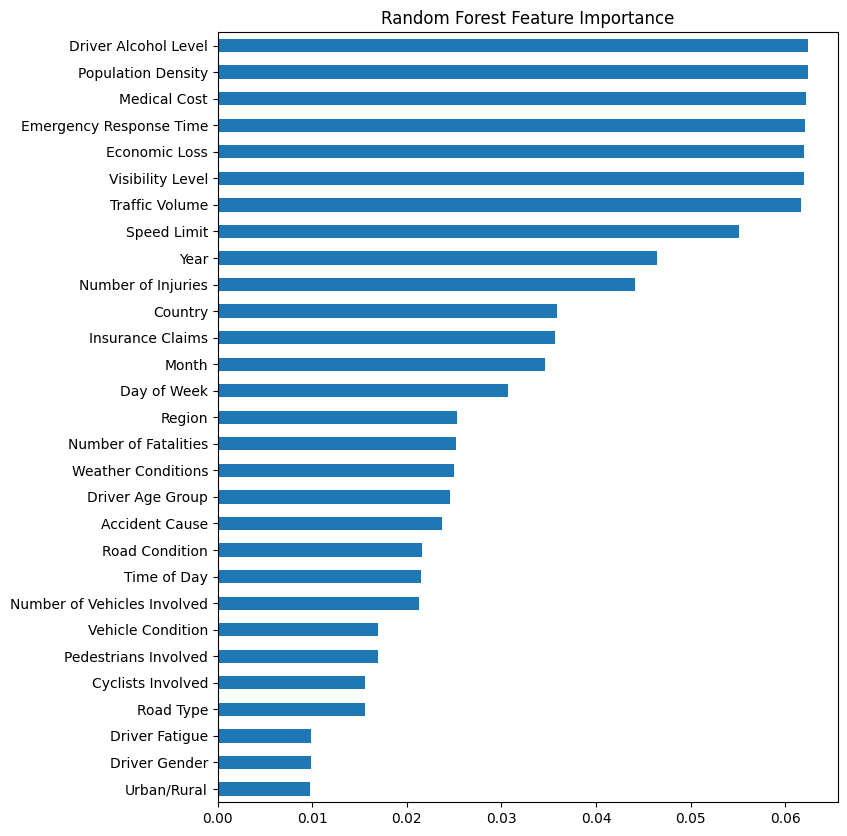

Driver Alcohol Level           0.062438
Population Density             0.062411
Medical Cost                   0.062190
Emergency Response Time        0.062049
Economic Loss                  0.061978
Visibility Level               0.061971
Traffic Volume                 0.061714
Speed Limit                    0.055105
Year                           0.046412
Number of Injuries             0.044141
Country                        0.035911
Insurance Claims               0.035620
Month                          0.034555
Day of Week                    0.030672
Region                         0.025347
Number of Fatalities           0.025163
Weather Conditions             0.025031
Driver Age Group               0.024573
Accident Cause                 0.023697
Road Condition                 0.021613
Time of Day                    0.021494
Number of Vehicles Involved    0.021335
Vehicle Condition              0.016996
Pedestrians Involved           0.016920
Cyclists Involved              0.015611


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Prepare X, y
X = encoded_data.drop(columns=['Accident Severity'])   # change TARGET
y = encoded_data['Accident Severity']                     # change TARGET

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Feature importances
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,10))
plt.title("Random Forest Feature Importance")
plt.show()

importances.sort_values(ascending=False)


In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer, f1_score

f1 = make_scorer(f1_score)

cv_acc = cross_val_score(rf, X, y, cv=5, scoring='accuracy')
cv_f1 = cross_val_score(rf, X, y, cv=5, scoring=f1)

print("Cross-Validation Accuracy:", cv_acc)
print("Mean Accuracy:", cv_acc.mean())

print("\nCross-Validation F1:", cv_f1)
print("Mean F1:", cv_f1.mean())


KeyboardInterrupt: 